In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
import pandas as pd
import scipy as sp
from QAESimulator import QAEAnalyticDistFunc
from MLEUtil import FindAmpSqMLE, FindAmpSqMLERandom, FindAmpSqMLESmart

In [2]:
np.random.seed(1)

In [3]:
ampSqTrue = 0.3
nShot = 2 ** 6
nGroverMax = 2 ** 12
nEstim = 30
nEstim = 50000

In [35]:
# 探索するthetaの値
thetaTrue = np.arcsin(np.sqrt(ampSqTrue))
#delTheta = 0.001
numTheta = 1000
#thetas = np.linspace(thetaTrue - delTheta, thetaTrue + delTheta, num=numTheta)
print(thetaTrue)

0.5796397403637042


seedを変えながら、Tanaka+ 2006.16223の最尤点探索手法が失敗するケースを探す

In [5]:
estims = []
n1Mat = []
for i in range(nEstim):
    np.random.seed(i)
    nGrovers, n1s = QAEAnalyticDistFunc(ampSqTrue, nShot, nGroverMax)
    estim = FindAmpSqMLESmart(nGrovers, n1s, nShot, numTheta)
    estims += [estim]
    print(i)
    print(estim)
    if abs(estim - ampSqTrue) > 0.01 : break

errors = np.array(estims) - ampSqTrue

0
0.3000078216077736
1
0.30000800511515857
2
0.3000032468806763
3
0.29999399539719124
4
0.300868787152918


C:\Users\koich\Desktop\Code\QAEErrorVsNShotNGrover\MLEUtil.py:9: RuntimeWarning: divide by zero encountered in log
  ret += n1 * np.log(p) + (nShot - n1) * np.log(1.0 - p)


5
0.29997228758357497
6
0.3000020995416874
7
0.2235004995891749


seed 7 だと失敗

In [7]:
np.random.seed(7)
nGrovers, n1s = QAEAnalyticDistFunc(ampSqTrue, nShot, nGroverMax)
print(FindAmpSqMLESmart(nGrovers, n1s, nShot, numTheta))

0.2235004995891749


seed 7での"1"の回数

In [8]:
print(n1s)

[14, 61, 3, 47, 17, 5, 0, 16, 61, 51, 10, 3, 3, 56]


14 / 64はすごくレアでもない（Pr(n1≦14)=0.097）

In [14]:
sp.stats.binom.cdf(14, 64, 0.3, loc=0)

0.09742939718427399

Tanakaの手法の各ステップのログ

In [17]:
from MLEUtil import LikelihoodQAE

In [24]:
sigmaNum = 5.0 # 5σ

thetaMax = np.arcsin(np.sqrt(n1s[0] / nShot)) # MLE for nGrover=0

for k in range(len(nGrovers)):
    sigma = 1.0 / (2.0 * (2.0 * nGrovers[k] + 1.0) * np.sqrt(nShot)) # 1/sqrt{Fisher info}
    thetaLB = max(thetaMax - sigmaNum * sigma, 0.0)
    thetaUB = min(thetaMax + sigmaNum * sigma, 0.5 * np.pi)

    # random search
    likMax = LikelihoodQAE(thetaMax, nGrovers[:(k + 1)], n1s[:(k + 1)], nShot)
    print(thetaMax, likMax, thetaLB, thetaUB)
    for _ in range(1000):
        thetaTemp = np.random.uniform(thetaLB, thetaUB)
        likTemp = LikelihoodQAE(thetaTemp, nGrovers[:(k + 1)], n1s[:(k + 1)], nShot)
        if likTemp > likMax:
            thetaMax = thetaTemp
            likMax = likTemp
            
    print(thetaMax, likMax)

0.4866949550747732 -33.620564448998074 0.17419495507477317 0.7991949550747732
0.4866949550747732 -33.620564448998074
0.4866949550747732 -47.587005021362515 0.3825282884081065 0.5908616217414399
0.45443919201829897 -45.880271640638746
0.45443919201829897 -100.93909696744237 0.39193919201829897 0.516939192018299
0.5080766697086028 -79.15390114217222
0.5080766697086028 -147.10583149430832 0.47335444748638056 0.542798891930825
0.4812830375167451 -126.49632129686248
0.4812830375167451 -234.88130700252464 0.46290068457556865 0.4996653904579216
0.4996650567378387 -190.616579022622
0.4996650567378387 -234.50371455104658 0.4901953597681417 0.5091347537075357
0.49283137242353575 -225.03043405536116
0.49283137242353575 -251.2191759251469 0.48802368011584346 0.49763906473122804
0.4880239034504787 -235.75702568918783
0.4880239034504787 -303.5671908537549 0.48560142283032365 0.49044638407063373
0.4904297830329305 -277.4278886122848
0.4904297830329305 -399.85782929604636 0.4892138297255375 0.49164573

ステージ1で最尤点が外れてしまっている　（注：ステージ番号は0,1,2,3,...（0がGrover0回））

C:\Users\koich\Desktop\Code\QAEErrorVsNShotNGrover\MLEUtil.py:9: RuntimeWarning: divide by zero encountered in log
  ret += n1 * np.log(p) + (nShot - n1) * np.log(1.0 - p)


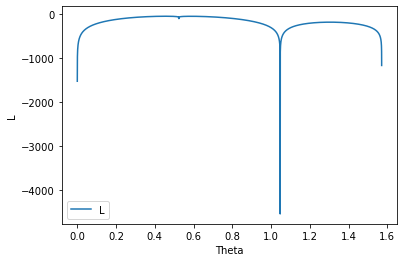

In [29]:
thetas = np.linspace(0, 0.5 * np.pi, num=100000)
liks = [LikelihoodQAE(theta, nGrovers[:2], n1s[:2], nShot) for theta in thetas]

plt.xlabel('Theta')
plt.ylabel('L')
ax = plt.gca()
plt.plot(thetas, liks, label="L")
#ax.set_ylim(-500, 0)
ax.legend()
plt.show()

In [30]:
thetas[np.nanargmax(liks)]

0.45443592170098057

In [32]:
np.nanmax(liks)

-45.8802716476656

In [31]:
LikelihoodQAE(thetaTrue, nGrovers[:2], n1s[:2], nShot)

-47.1483867097441

ステージ2までの尤度を一度に勘案すると成功するが、ステージ1で失敗するとリカバリできず

In [33]:
liks_UpTpStage2 = [LikelihoodQAE(theta, nGrovers[:3], n1s[:3], nShot) for theta in thetas]

C:\Users\koich\Desktop\Code\QAEErrorVsNShotNGrover\MLEUtil.py:9: RuntimeWarning: divide by zero encountered in log
  ret += n1 * np.log(p) + (nShot - n1) * np.log(1.0 - p)


In [34]:
thetas[np.nanargmax(liks_UpTpStage2)]

0.5852531479687223

ステージ1までのnShotを増やして失敗しないか確認

In [47]:
for i in range(10):
    np.random.seed(i)
    nGrovers, n1s = QAEAnalyticDistFunc(ampSqTrue, nShot = 512, nGroverMax = 2)
    print(FindAmpSqMLESmart(nGrovers, n1s, nShot = 512, numPoints = 1000))

0.30034673607974366
0.2949923837996222
0.3014784889402465
0.29894653796141396
0.30271184602911033
0.293996287372317
0.3077040741528237
0.2973674392184208
0.3069656726371248
0.30261280854159295


In [52]:
sigmaNum = 5.0 # 5σ
nShot = 512
nGroverMax = 2

for i in range(10):
    print(i)
    np.random.seed(i)
    nGrovers, n1s = QAEAnalyticDistFunc(ampSqTrue, nShot, nGroverMax)

    thetaMax = np.arcsin(np.sqrt(n1s[0] / nShot)) # MLE for nGrover=0

    for k in range(len(nGrovers)):
        sigma = 1.0 / (2.0 * (2.0 * nGrovers[k] + 1.0) * np.sqrt(nShot)) # 1/sqrt{Fisher info}
        thetaLB = max(thetaMax - sigmaNum * sigma, 0.0)
        thetaUB = min(thetaMax + sigmaNum * sigma, 0.5 * np.pi)

        # random search
        likMax = LikelihoodQAE(thetaMax, nGrovers[:(k + 1)], n1s[:(k + 1)], nShot)
        print(thetaMax, likMax, thetaLB, thetaUB)
        for _ in range(1000):
            thetaTemp = np.random.uniform(thetaLB, thetaUB)
            likTemp = LikelihoodQAE(thetaTemp, nGrovers[:(k + 1)], n1s[:(k + 1)], nShot)
            if likTemp > likMax:
                thetaMax = thetaTemp
                likMax = likTemp

        print(thetaMax, likMax)

0
0.5868627382717702 -315.58980131677106 0.4763773037113721 0.6973481728321682
0.5868627382717702 -315.58980131677106
0.5868627382717702 -383.63587521433817 0.5500342600849708 0.6236912164585695
0.581587317536196 -383.35445508722614
0.581587317536196 -497.6935611705973 0.5594902306241164 0.6036844044482755
0.5800179980340033 -497.6042769594777
1
0.5762249701757143 -311.3949175295379 0.4657395356153162 0.6867104047361123
0.5762249701757143 -311.3949175295379
0.5762249701757143 -335.23565125995754 0.5393964919889149 0.6130534483625136
0.5520711845123212 -330.4836934463457
0.5520711845123212 -456.13961957704043 0.5299740976002416 0.5741682714244007
0.5741627819588666 -441.7092265510528
2
0.6078630298886254 -323.2944174708107 0.49737759532822734 0.7183484644490234
0.6078630298886254 -323.2944174708107
0.6078630298886254 -396.9747059150228 0.571034551701826 0.6446915080754247
0.5836660726871958 -391.6977512192858
0.5836660726871958 -503.42441845306337 0.5615689857751163 0.6057631595992754
0

seed 1で失敗

In [53]:
np.random.seed(1)
nGrovers, n1s = QAEAnalyticDistFunc(ampSqTrue, nShot, nGroverMax)
print(n1s)

[152, 509, 27]


In [57]:
liks_UpTpStage1 = [LikelihoodQAE(theta, nGrovers[:2], n1s[:2], nShot) for theta in thetas]
print(thetas[np.nanargmax(liks_UpTpStage1)])
print(np.nanmax(liks_UpTpStage1))
print(LikelihoodQAE(thetaTrue, nGrovers[:2], n1s[:2], nShot))

0.5519990571895665
-330.4836532790975
-336.58883091345086


Nshot=512でも失敗するということなら、median trickでも使うしかないか...

極端にNshotを上げる

In [61]:
sigmaNum = 5.0 # 5σ
nShot = 2 ** 10
nGroverMax = 2

for i in range(10):
    print(i)
    np.random.seed(i)
    nGrovers, n1s = QAEAnalyticDistFunc(ampSqTrue, nShot, nGroverMax)

    thetaMax = np.arcsin(np.sqrt(n1s[0] / nShot)) # MLE for nGrover=0

    for k in range(len(nGrovers)):
        sigma = 1.0 / (2.0 * (2.0 * nGrovers[k] + 1.0) * np.sqrt(nShot)) # 1/sqrt{Fisher info}
        thetaLB = max(thetaMax - sigmaNum * sigma, 0.0)
        thetaUB = min(thetaMax + sigmaNum * sigma, 0.5 * np.pi)

        # random search
        likMax = LikelihoodQAE(thetaMax, nGrovers[:(k + 1)], n1s[:(k + 1)], nShot)
        print(thetaMax, likMax, thetaLB, thetaUB)
        for _ in range(1000):
            thetaTemp = np.random.uniform(thetaLB, thetaUB)
            likTemp = LikelihoodQAE(thetaTemp, nGrovers[:(k + 1)], n1s[:(k + 1)], nShot)
            if likTemp > likMax:
                thetaMax = thetaTemp
                likMax = likTemp

        print(thetaMax, likMax)

0
0.5826193310685988 -627.8792816048272 0.5044943310685988 0.6607443310685988
0.5826193310685988 -627.8792816048272
0.5826193310685988 -763.3954834554506 0.5565776644019321 0.6086609977352654
0.5811327331183 -763.3489496276496
0.5811327331183 -989.0843009460318 0.5655077331183 0.5967577331183
0.5802181129606511 -989.0212656283945
1
0.5762249701757143 -622.7898350590758 0.4980999701757143 0.6543499701757143
0.5762249701757143 -622.7898350590758
0.5762249701757143 -688.8470203800794 0.5501833035090476 0.6022666368423809
0.5600576472690261 -684.1998031935829
0.5600576472690261 -940.432456119001 0.5444326472690261 0.5756826472690261
0.5727965424596461 -930.2847859790882
2
0.5984558839454068 -639.8780758552418 0.5203308839454068 0.6765808839454068
0.5984558839454068 -639.8780758552418
0.5984558839454068 -777.6006634838955 0.5724142172787402 0.6244975506120735
0.5818240569404872 -772.4569285359587
0.5818240569404872 -1015.5991794788528 0.5661990569404872 0.5974490569404872
0.5786350603798025

In [63]:
sigmaNum = 5.0 # 5σ
nShot = 2 ** 12
nGroverMax = 2

for i in range(10):
    print(i)
    np.random.seed(i)
    nGrovers, n1s = QAEAnalyticDistFunc(ampSqTrue, nShot, nGroverMax)

    thetaMax = np.arcsin(np.sqrt(n1s[0] / nShot)) # MLE for nGrover=0

    for k in range(len(nGrovers)):
        sigma = 1.0 / (2.0 * (2.0 * nGrovers[k] + 1.0) * np.sqrt(nShot)) # 1/sqrt{Fisher info}
        thetaLB = max(thetaMax - sigmaNum * sigma, 0.0)
        thetaUB = min(thetaMax + sigmaNum * sigma, 0.5 * np.pi)

        # random search
        likMax = LikelihoodQAE(thetaMax, nGrovers[:(k + 1)], n1s[:(k + 1)], nShot)
        print(thetaMax, likMax, thetaLB, thetaUB)
        for _ in range(100):
            thetaTemp = np.random.uniform(thetaLB, thetaUB)
            likTemp = LikelihoodQAE(thetaTemp, nGrovers[:(k + 1)], n1s[:(k + 1)], nShot)
            if likTemp > likMax:
                thetaMax = thetaTemp
                likMax = likTemp

        print(thetaMax, likMax)

0
0.5802256250596592 -2503.9614240379433 0.5411631250596592 0.6192881250596592
0.5802256250596592 -2503.9614240379433
0.5802256250596592 -3031.7526285428394 0.5672047917263259 0.5932464583929926
0.579977156534075 -3031.74805133511
0.579977156534075 -3920.3443735598416 0.572164656534075 0.587789656534075
0.5802615426892416 -3920.3219667414996
1
0.577293191118055 -2494.5988834685877 0.538230691118055 0.616355691118055
0.577293191118055 -2494.5988834685877
0.577293191118055 -2993.8444648525947 0.5642723577847216 0.5903140244513884
0.5779356470848189 -2993.8143960229127
0.5779356470848189 -3910.7140401511942 0.5701231470848189 0.5857481470848189
0.5790115531895801 -3910.4465756125333
2
0.5889787696260641 -2531.208684420889 0.5499162696260641 0.6280412696260641
0.5889787696260641 -2531.208684420889
0.5889787696260641 -3090.570997329263 0.5759579362927307 0.6019996029593975
0.5828271688260646 -3087.3751423932695
0.5828271688260646 -4021.1034969256584 0.5750146688260646 0.5906396688260646
0.5

Nshotを上げれば成功確率は上がるが、特定の最尤点探索手法における成功確率向上のためにNshotを上げるのはイケてない。
Tanakaの手法でやたらエラーが大きければランダムサーチに変える、というやり方にするか...。
（答を知ってる前提なのでそれもイケてないけど）